In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw = pd.read_csv(url)
raw.shape  # expect ~7214 rows


(7214, 53)

In [3]:
cols = [
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex",
    "priors_count", "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]
df = raw[cols].copy()
df.shape


(7214, 13)

In [16]:
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]

df = df[df["is_recid"] != -1]

df = df[df["c_charge_degree"] != "O"]

df = df[~df["score_text"].isna()]

df.shape

(6172, 21)

In [17]:
df.head()


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,...,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor,score_binary,pred_prob,pred_class
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,...,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore,0,0.023951,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,...,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore,0,0.410362,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,...,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore,0,0.883057,1
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,...,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore,0,0.065185,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,...,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore,1,0.949096,1


In [6]:
df.describe(include="all")

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out
count,6172.000000,6172,6172,6172,6172,6172,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172,6172
unique,NaN,2,6,3,3,2,NaN,NaN,NaN,NaN,NaN,6172,6161
top,NaN,F,African-American,25 - 45,Low,Male,NaN,NaN,NaN,NaN,NaN,2014-06-28 12:16:41,2013-09-14 05:58:00
freq,NaN,3970,3175,3532,3421,4997,NaN,NaN,NaN,NaN,NaN,1,3
mean,34.534511,NaN,NaN,NaN,NaN,NaN,3.246436,-1.740279,4.418503,0.484446,0.455120,NaN,NaN
std,11.730938,NaN,NaN,NaN,NaN,NaN,4.743770,5.084709,2.839463,0.499799,0.498022,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-30.000000,1.000000,0.000000,0.000000,NaN,NaN
25%,25.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-1.000000,2.000000,0.000000,0.000000,NaN,NaN
50%,31.000000,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,4.000000,0.000000,0.000000,NaN,NaN
75%,42.000000,NaN,NaN,NaN,NaN,NaN,4.000000,-1.000000,7.000000,1.000000,1.000000,NaN,NaN


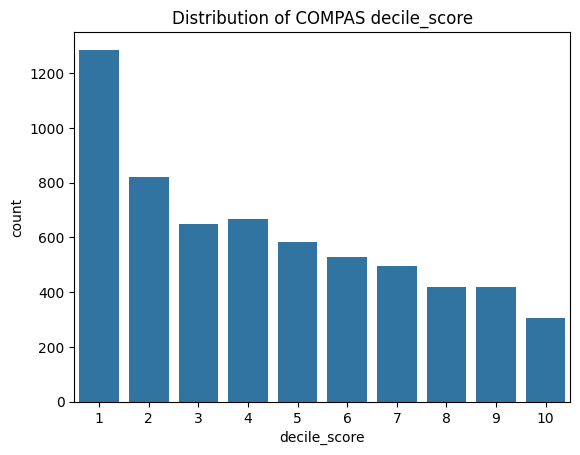

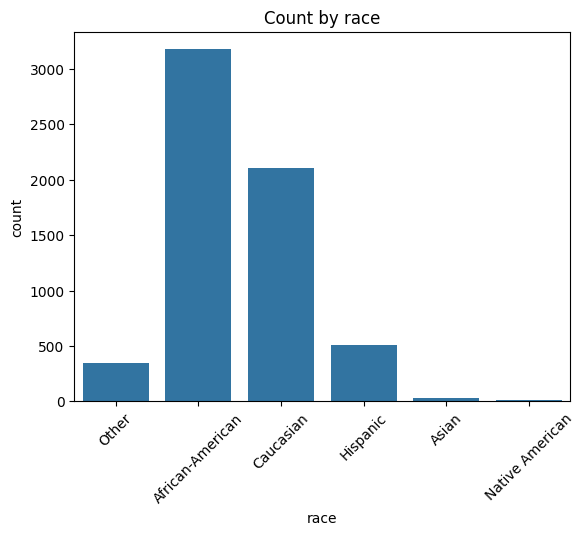

In [18]:
sns.countplot(x="decile_score", data=df)
plt.title("Distribution of COMPAS decile_score")
plt.show()

sns.countplot(x="race", data=df)
plt.title("Count by race")
plt.xticks(rotation=45)
plt.show()


In [19]:
df["crime_factor"] = df["c_charge_degree"].astype("category")

age_cat = pd.Categorical(
    df["age_cat"],
    categories=["Less than 25", "25 - 45", "Greater than 45"],
    ordered=True
)
df["age_factor"] = age_cat

race_cat = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Hispanic", "Asian", "Native American", "Other"],
    ordered=False
)
df["race_factor"] = race_cat

sex_cat = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"],
    ordered=False
)
df["gender_factor"] = sex_cat

df["score_factor"] = np.where(df["score_text"] == "Low", "LowScore", "HighScore")
df["score_factor"] = df["score_factor"].astype("category")

df["two_year_recid"] = df["two_year_recid"].astype(int)


In [9]:
df[["age_factor", "race_factor", "gender_factor", "crime_factor", "score_factor"]].head()


,age_factor,race_factor,gender_factor,crime_factor,score_factor
0,Greater than 45,Other,Male,F,LowScore
1,25 - 45,African-American,Male,F,LowScore
2,Less than 25,African-American,Male,F,LowScore
5,25 - 45,Other,Male,M,LowScore
6,25 - 45,Caucasian,Male,F,HighScore


In [20]:
df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

formula = "score_binary ~ C(gender_factor) + C(age_factor) + C(race_factor) + priors_count + C(crime_factor) + two_year_recid"

model = smf.logit(formula=formula, data=df).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        19:37:32   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.2171      0.088    

In [21]:
df["pred_prob"] = model.predict(df)
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)  # 1 = HighScore predicted

cm = confusion_matrix(df["score_binary"], df["pred_class"])
cm


array([[2744,  677],
       [ 854, 1897]])

In [23]:
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

accuracy, precision, recall, fpr, fnr


(np.float64(0.7519442644199611),
 np.float64(0.736985236985237),
 np.float64(0.6895674300254453),
 np.float64(0.19789535223618826),
 np.float64(0.3104325699745547))

In [24]:
metrics_rows = []

for race in df["race_factor"].cat.categories:
    sub = df[df["race_factor"] == race]
    if sub.empty:
        continue

    cm_r = confusion_matrix(sub["score_binary"], sub["pred_class"])
    if cm_r.shape == (2, 2):
        tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
    else:
        tn_r = fp_r = fn_r = tp_r = np.nan

    n = len(sub)
    accuracy_r = (tp_r + tn_r) / n if n > 0 else np.nan
    precision_r = tp_r / (tp_r + fp_r) if (tp_r + fp_r) > 0 else np.nan
    recall_r = tp_r / (tp_r + fn_r) if (tp_r + fn_r) > 0 else np.nan
    fpr_r = fp_r / (fp_r + tn_r) if (fp_r + tn_r) > 0 else np.nan
    fnr_r = fn_r / (fn_r + tp_r) if (fn_r + tp_r) > 0 else np.nan

    metrics_rows.append({
        "race": race,
        "n": n,
        "TP": tp_r,
        "TN": tn_r,
        "FP": fp_r,
        "FN": fn_r,
        "Accuracy": round(accuracy_r, 3) if not np.isnan(accuracy_r) else np.nan,
        "Precision": round(precision_r, 3) if not np.isnan(precision_r) else np.nan,
        "Recall": round(recall_r, 3) if not np.isnan(recall_r) else np.nan,
        "FPR": round(fpr_r, 3) if not np.isnan(fpr_r) else np.nan,
        "FNR": round(fnr_r, 3) if not np.isnan(fnr_r) else np.nan,
    })

race_metrics = pd.DataFrame(metrics_rows).sort_values("n", ascending=False)
race_metrics


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR
1,African-American,3175,1445,863,483,384,0.727,0.749,0.790,0.359,0.210
0,Caucasian,2103,358,1251,156,338,0.765,0.696,0.514,0.111,0.486
2,Hispanic,509,65,338,30,76,0.792,0.684,0.461,0.082,0.539
5,Other,343,18,266,7,52,0.828,0.720,0.257,0.026,0.743
3,Asian,31,3,24,0,4,0.871,1.000,0.429,0.000,0.571
4,Native American,11,8,2,1,0,0.909,0.889,1.000,0.333,0.000


In [25]:
ref = "Caucasian"
ref_row = race_metrics[race_metrics["race"] == ref].iloc[0]

race_metrics["delta_FPR_vs_Caucasian"] = race_metrics["FPR"] - ref_row["FPR"]
race_metrics["delta_FNR_vs_Caucasian"] = race_metrics["FNR"] - ref_row["FNR"]

race_metrics


,race,n,TP,TN,FP,FN,Accuracy,Precision,Recall,FPR,FNR,delta_FPR_vs_Caucasian,delta_FNR_vs_Caucasian
1,African-American,3175,1445,863,483,384,0.727,0.749,0.790,0.359,0.210,0.248,-0.276
0,Caucasian,2103,358,1251,156,338,0.765,0.696,0.514,0.111,0.486,0.000,0.000
2,Hispanic,509,65,338,30,76,0.792,0.684,0.461,0.082,0.539,-0.029,0.053
5,Other,343,18,266,7,52,0.828,0.720,0.257,0.026,0.743,-0.085,0.257
3,Asian,31,3,24,0,4,0.871,1.000,0.429,0.000,0.571,-0.111,0.085
4,Native American,11,8,2,1,0,0.909,0.889,1.000,0.333,0.000,0.222,-0.486


In [26]:
calib = (
    df.groupby(["decile_score", "race_factor"])
      .agg(
          mean_score=("score_binary", "mean"),
          mean_recid=("two_year_recid", "mean"),
          n=("two_year_recid", "size")
      )
      .reset_index()
)

calib.head()


/tmp/ipykernel_1156/918755385.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["decile_score", "race_factor"])


,decile_score,race_factor,mean_score,mean_recid,n
0,1,Caucasian,0.0,0.211570,605
1,1,African-American,0.0,0.232877,365
2,1,Hispanic,0.0,0.238994,159
3,1,Asian,0.0,0.066667,15
4,1,Native American,NaN,NaN,0
